# Exploring Warren-Associated Geoscience Metadata with DSI and NAVDAT

## User Story

As a geoscientist evaluating federated EarthChem metadata, I want to retrieve
sample and citation records matching the author name `Warren`, examine their
geographic distribution, and summarize their analytical methods so that I can
understand the scope of records returned through the DSI NAVDAT backend.

## Scientific Question

What geographic regions, publications, analysis types, and analytical methods
are represented in PetDB records returned for the author query `Warren`?

## Overall Story

This notebook uses the DSI NAVDAT backend to query the EarthChem PetDB v4 API.
DSI converts the nested API responses into two tables:

- `samples` — sample identifiers, location groups, coordinates, and document
  counts.
- `citations` — publication, dataset, DOI, analysis-type, and method metadata.

The notebook maps the returned samples, identifies the largest location
groups, and summarizes the citation and analytical-method metadata.

Because PetDB is a federated system, the results are not necessarily limited
to records from the original legacy NAVDAT collection.

In [1]:
# Configure Python to use the macOS system certificate store.

import ssl

try:
    import truststore

    if not getattr(ssl, "_navdat_truststore_active", False):
        truststore.inject_into_ssl()
        ssl._navdat_truststore_active = True

    print("Using the macOS system certificate store.")
except ImportError:
    print(
        "truststore is not installed. "
        "Python's default certificate store will be used."
    )

Using the macOS system certificate store.


In [2]:
# Import the packages used for retrieval, analysis, and visualization.

import sys
from io import BytesIO

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display

from dsi.dsi import DSI

pd.set_option("display.max_columns", 50)
pd.set_option("display.max_colwidth", 120)


def display_figure(fig):
    """Render a Matplotlib figure directly inside the notebook."""
    image_buffer = BytesIO()

    fig.savefig(
        image_buffer,
        format="png",
        dpi=120,
        bbox_inches="tight",
    )

    image_buffer.seek(0)
    display(Image(data=image_buffer.getvalue()))
    plt.close(fig)


print("Python environment:", sys.executable)
print("Matplotlib backend:", matplotlib.get_backend())

Python environment: /Users/rsankararaman/Navdat_new/.venv/bin/python
Matplotlib backend: module://matplotlib_inline.backend_inline


## 1. Define the Author Query

The query uses `Warren` as an author search term and requests 100 sample
location groups.

The author filter is surname-based and may return records associated with
different researchers named Warren. Pagination is not currently implemented,
so this notebook analyzes the returned API page rather than the complete
PetDB collection.

In [3]:
# Define the author query and the requested page size.

AUTHOR_QUERY = "Warren"
SAMPLE_PAGE_SIZE = 100

query_params = {
    "authors": AUTHOR_QUERY,
    "size": SAMPLE_PAGE_SIZE,
}

query_params

{'authors': 'Warren', 'size': 100}

## 2. Retrieve the Metadata Through DSI

The read-only NAVDAT backend queries the EarthChem PetDB v4 API and normalizes
the returned sample and citation metadata into in-memory DSI tables.

In [4]:
# Initialize the NAVDAT backend with the Warren author query.

dsi = DSI(
    backend_name="NAVDAT",
    params=query_params,
)

print(f"NAVDAT initialized for author query: {AUTHOR_QUERY}")

Created an instance of DSI with the NAVDAT read-only backend
NAVDAT initialized for author query: Warren


In [5]:
# List the tables populated by the NAVDAT backend.

dsi.list()

Table: samples
  - num of columns: 10
  - num of rows: 321

Table: citations
  - num of columns: 15
  - num of rows: 71




### Normalized DSI tables

The backend returned:

- **samples** — individual samples flattened from grouped location responses.
- **citations** — citation, dataset, analysis-type, and method records.

The tables come from the same author query, but the API does not provide a
confirmed key for joining an individual sample to a citation.

In [6]:
# Retrieve the normalized samples table.

samples = dsi.get_table(
    "samples",
    collection=True,
).copy()

print("Sample rows:", len(samples))

Storing all data for the table: samples as a collection
Sample rows: 321


In [7]:
# Retrieve the citations table when the query returns citation records.

try:
    citations = dsi.get_table(
        "citations",
        collection=True,
    ).copy()
except (ValueError, KeyError, RuntimeError):
    citations = pd.DataFrame()
    print("The query did not return a citations table.")

print("Citation/dataset rows:", len(citations))

Storing all data for the table: citations as a collection
Citation/dataset rows: 71


## 3. Inspect the Retrieved Samples

The samples table contains sample identifiers, PetDB location groups,
coordinates, and document counts. A focused view is used to show the fields
needed for the geographic analysis.

In [8]:
# Select the sample fields most relevant to this user story.

preferred_sample_columns = [
    "sampleId",
    "sampleName",
    "rootParent",
    "sampleLat",
    "sampleLon",
    "sampleDocCount",
    "groupDocCount",
    "sampleCount",
]

sample_columns = [
    column
    for column in preferred_sample_columns
    if column in samples.columns
]

display(samples[sample_columns].head(8))

,sampleId,sampleName,rootParent,sampleLat,sampleLon,sampleDocCount,groupDocCount,sampleCount
0,235a4b01cca43ead1a2435ec19c04bab,A2107-6-60-4,AII0107-6,-53.4180,9.198,4,8,2
1,c50eba02bbfa2d21fb54ec0977e952d5,A2107-6-61-83,AII0107-6,-53.4180,9.198,4,8,2
2,4158345f3687fcb84c1795cbf3c2e638,CIRCE97-W-OL,ARGCIRC-097,-17.0500,66.867,4,4,1
3,222a86bb1133ab54e1f848877d3bec6f,NJ88-A1,ARGNOVA-088,-20.3800,-173.270,29,104,4
4,b3a5a8d174275337ad689abe950c67e9,NJ88-D1,ARGNOVA-088,-20.3800,-173.270,26,104,4
5,6ba2e728c50327b52067a8030fa08bff,NJ88-C1,ARGNOVA-088,-20.3800,-173.270,25,104,4
6,9b60f4db48131e756a15137b80c9020b,NJ88-F1,ARGNOVA-088,-20.3800,-173.270,24,104,4
7,d5355e263584a35e4343c071127b8d2d,BMRG08-82-2-8,BMRG08MV-082,-25.8542,-175.420,43,126,3


## 4. Validate the Coordinates

Latitude and longitude are converted to numeric values and checked against
valid geographic ranges before the samples are plotted.

In [9]:
# Prepare valid coordinates and summarize the retrieved sample data.

samples_work = samples.copy()

samples_work["latitude"] = pd.to_numeric(
    samples_work["sampleLat"],
    errors="coerce",
)

samples_work["longitude"] = pd.to_numeric(
    samples_work["sampleLon"],
    errors="coerce",
)

valid_coordinates = (
    samples_work["latitude"].between(-90, 90)
    & samples_work["longitude"].between(-180, 180)
)

samples_geo = samples_work.loc[valid_coordinates].copy()

sample_summary = pd.DataFrame(
    {
        "metric": [
            "Retrieved sample rows",
            "Unique sample IDs",
            "Valid coordinate rows",
            "Location groups",
        ],
        "value": [
            len(samples_work),
            samples_work["sampleId"].nunique(),
            len(samples_geo),
            samples_work["rootParent"].nunique(),
        ],
    }
)

sample_summary

,metric,value
0,Retrieved sample rows,321
1,Unique sample IDs,321
2,Valid coordinate rows,321
3,Location groups,100


## 5. Map the Retrieved Samples

The coordinate plot shows the geographic distribution of samples returned by
the `Warren` author query. Point color represents the sample-level document
count.

The result is a global distribution, demonstrating that a surname query can
retrieve records associated with several authors and geographic regions.

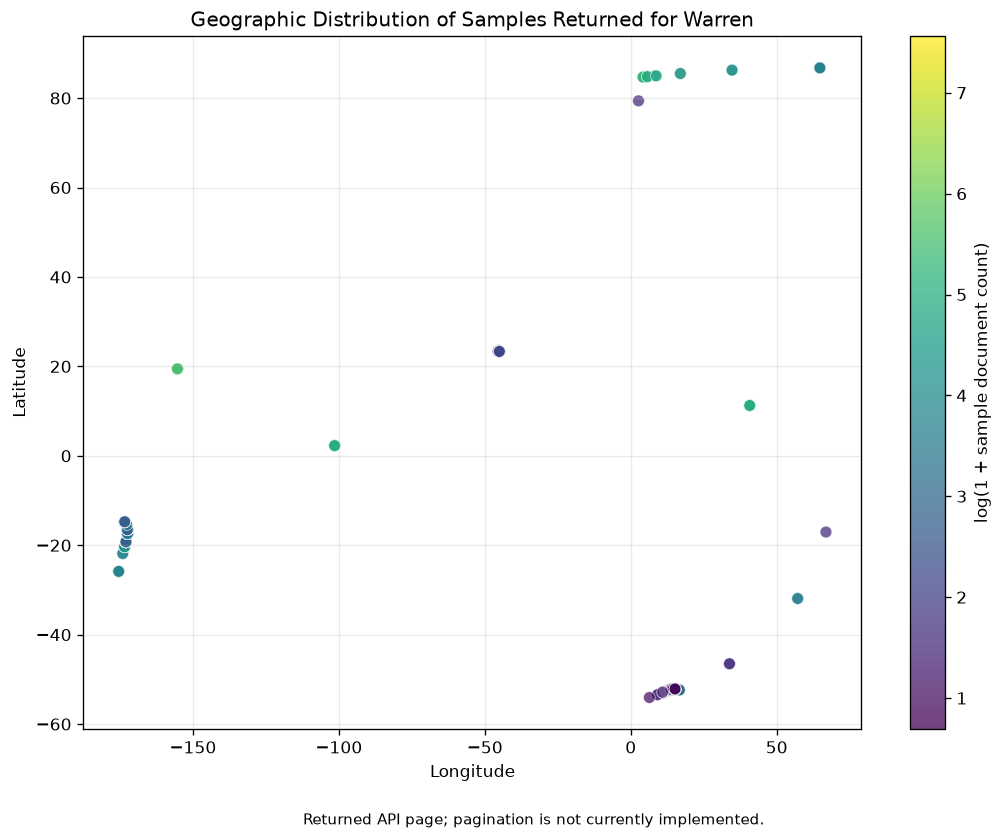

In [10]:
# Plot the geographic distribution of samples with valid coordinates.

if samples_geo.empty:
    print("No valid coordinates are available for mapping.")
else:
    if "sampleDocCount" in samples_geo.columns:
        document_counts = pd.to_numeric(
            samples_geo["sampleDocCount"],
            errors="coerce",
        ).fillna(0).clip(lower=0)
    else:
        document_counts = pd.Series(
            0,
            index=samples_geo.index,
            dtype=float,
        )

    color_values = np.log1p(document_counts)

    fig, ax = plt.subplots(figsize=(9, 7))

    points = ax.scatter(
        samples_geo["longitude"],
        samples_geo["latitude"],
        c=color_values,
        s=50,
        alpha=0.75,
        cmap="viridis",
        edgecolor="white",
        linewidth=0.4,
    )

    ax.set_title(
        "Geographic Distribution of Samples Returned for Warren"
    )
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.grid(alpha=0.25)

    colorbar = fig.colorbar(points, ax=ax)
    colorbar.set_label("log(1 + sample document count)")

    fig.text(
        0.5,
        0.01,
        "Returned API page; pagination is not currently implemented.",
        ha="center",
        fontsize=9,
    )

    plt.tight_layout(rect=[0, 0.04, 1, 1])
    display_figure(fig)

## 6. Identify the Largest Location Groups

PetDB organizes samples into location groups. The following summary identifies
the groups containing the largest number of sample records in the returned
page.

In [11]:
# Summarize the returned samples by their location group.

required_cluster_columns = {
    "rootParent",
    "sampleId",
    "latitude",
    "longitude",
}

if (
    samples_geo.empty
    or not required_cluster_columns.issubset(samples_geo.columns)
):
    cluster_summary = pd.DataFrame()
    print("Location-group information is unavailable.")
else:
    cluster_input = samples_geo.copy()

    cluster_input["location_group"] = (
        cluster_input["rootParent"]
        .fillna("Unspecified")
        .astype(str)
    )

    cluster_summary = (
        cluster_input
        .groupby("location_group", dropna=False)
        .agg(
            sample_records=("sampleId", "size"),
            unique_samples=("sampleId", "nunique"),
            center_latitude=("latitude", "mean"),
            center_longitude=("longitude", "mean"),
        )
        .sort_values(
            ["sample_records", "unique_samples"],
            ascending=False,
        )
        .reset_index()
    )

    display(cluster_summary.head(10))

,location_group,sample_records,unique_samples,center_latitude,center_longitude
0,BMRG08MV-098,21,21,-19.25200,-172.9480
1,KNO0180-2-019,16,16,23.51890,-45.3616
2,PETDB-5036-F02-26,15,15,19.42446,-155.2880
3,KNO0180-2-021,14,14,23.36420,-45.3770
4,KNO0180-2-027,14,14,23.40490,-45.4136
5,KNO0162-9-047,11,11,-52.56200,12.6620
6,PETDB-5036-AB21-4,10,10,19.33923,-155.2807
7,KNO0180-2-028,9,9,23.38340,-45.3823
8,KNO0180-2-005,8,8,23.47090,-45.3579
9,BMRG08MV-106,7,7,-17.41700,-172.4090


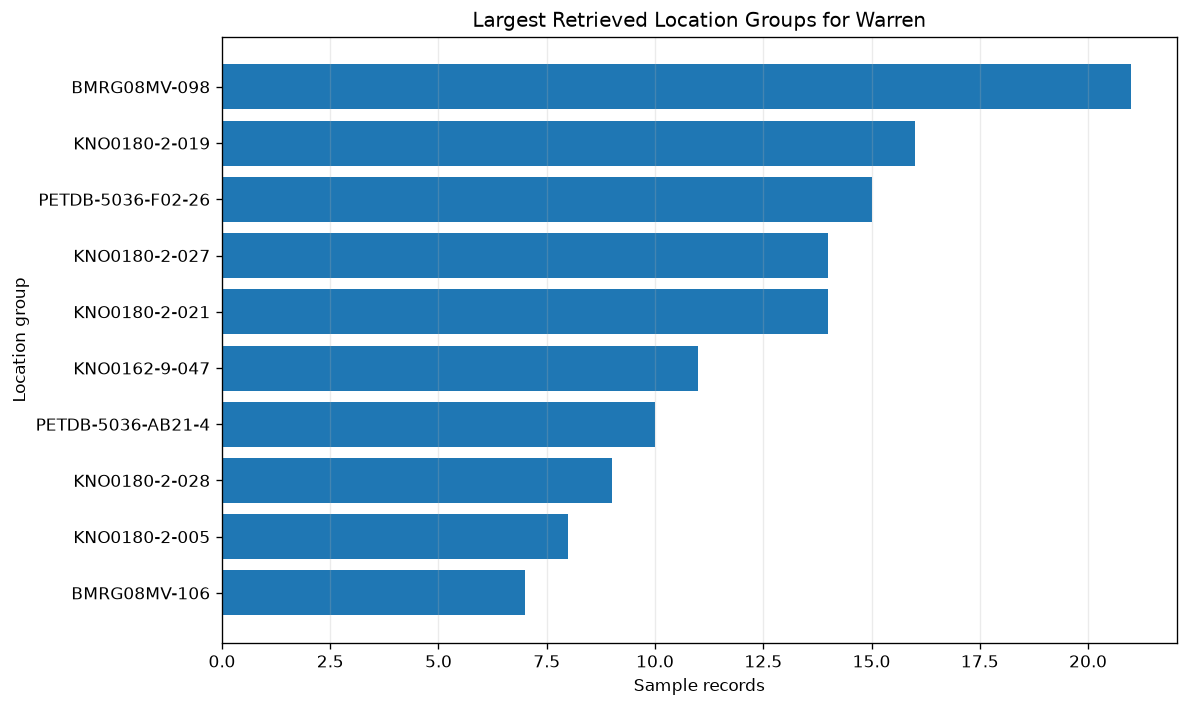

In [12]:
# Plot the location groups containing the most sample records.

if cluster_summary.empty:
    print("No location-group summary is available.")
else:
    top_clusters = (
        cluster_summary
        .head(10)
        .sort_values("sample_records")
        .copy()
    )

    top_clusters["display_name"] = (
        top_clusters["location_group"]
        .str.slice(0, 55)
    )

    fig, ax = plt.subplots(figsize=(10, 6))

    ax.barh(
        top_clusters["display_name"],
        top_clusters["sample_records"],
    )

    ax.set_title(
        f"Largest Retrieved Location Groups for {AUTHOR_QUERY}"
    )
    ax.set_xlabel("Sample records")
    ax.set_ylabel("Location group")
    ax.grid(axis="x", alpha=0.25)

    plt.tight_layout()
    display_figure(fig)

## 7. Examine the Citation Metadata

The citations table contains publication, dataset, DOI, analysis-type, and
analytical-method metadata.

A publication may appear in multiple rows because it can contain several
datasets or analysis types. The next step creates one row per citation for
publication-level analysis.

In [13]:
# Create one row per citation for publication-level analysis.

if citations.empty:
    unique_citations = pd.DataFrame()
    print("No citation records were returned.")
else:
    unique_citations = (
        citations
        .drop_duplicates(subset=["citationId"])
        .copy()
    )

    unique_citations["publication_year"] = pd.to_numeric(
        unique_citations["citationPublicationYear"],
        errors="coerce",
    )

    print("Citation/dataset rows:", len(citations))
    print("Unique citations:", len(unique_citations))

Citation/dataset rows: 71
Unique citations: 15


In [14]:
# Display the unique citations in reverse chronological order.

if unique_citations.empty:
    citation_view = pd.DataFrame()
    print("No unique citations are available.")
else:
    citation_view_columns = [
        "citationTitle",
        "citationAuthors",
        "citationPublicationYear",
        "citationContainerTitle",
        "citationDOIs",
    ]

    citation_view_columns = [
        column
        for column in citation_view_columns
        if column in unique_citations.columns
    ]

    citation_view = (
        unique_citations
        .sort_values("publication_year", ascending=False)
        [citation_view_columns]
    )

    display(citation_view)

,citationTitle,citationAuthors,citationPublicationYear,citationContainerTitle,citationDOIs
69,Electron Microprobe and Laser Ablation Inductively Coupled Mass Spectrometry analyses of glasses from the Kulanaokua...,"nalesnik, a.; lynn, k.; rose, t.; warren, j. m.; lin, k.",2025,None,10.60520/IEDA/113888
68,"DEEP, HOT, ANCIENT MELTING RECORDED BY ULTRALOW OXYGEN FUGACITY IN PERIDOTITES","birner, s.; cottrell, e.; davis, f.; warren, j. m.",2024,NATURE,10.1038/s41586-024-07603-w
61,HIGH TEMPERATURE HYDROTHERMAL ALTERATION AND AMPHIBOLE FORMATION IN GAKKEL RIDGE ABYSSAL PERIDOTITES,"patterson, s.; lynn, k.; prigent, c.; warren, j. m.",2021,LITHOS,10.1016/j.lithos.2021.106107
62,MELT ADDITION TO MID-OCEAN RIDGE PERIDOTITES INCREASES SPINEL CR# WITH NO SIGNIFICANT EFFECT ON RECORDED OXYGEN FUGA...,"birner, s.; cottrell, e.; warren, j. m.; kelley, k. a.; davis, f.",2021,EARTH AND PLANETARY SCIENCE LETTERS,10.1016/j.epsl.2021.116951
46,IN SITU MEASUREMENTS OF LEAD AND OTHER TRACE ELEMENTS IN ABYSSAL PERIDOTITE SULFIDES,"derrico, m.; warren, j. m.; coble, m.",2019,AMERICAN MINERALOGIST,10.2138/am-2019-6516
42,186OS–187OS AND HIGHLY SIDEROPHILE ELEMENT ABUNDANCE SYSTEMATICS OF THE MANTLE REVEALED BY ABYSSAL PERIDOTITES AND O...,"walker, r. j.; warren, j. m.; day, j. m. d.",2017,GEOCHIM COSMOCHIM ACTA,10.1016/j.gca.2016.12.013
50,FOREARC PERIDOTITES FROM TONGA RECORD HETEROGENEOUS OXIDATION OF THE MANTLE FOLLOWING SUBDUCTION INITIATION,"birner, s.; warren, j. m.; cottrell, e.; davis, f.; kelley, k. a.; falloon, t. j.",2017,JOURNAL OF PETROLOGY,10.1093/petrology/egx072
28,EVIDENCE FOR CHEMICALLY HETEROGENEOUS ARCTIC MANTLE BENEATH THE GAKKEL RIDGE,"derrico, m.; warren, j. m.; godard, m.",2016,GEOCHIM COSMOCHIM ACTA,10.1016/j.gca.2015.11.017
37,HYDROTHERMAL ALTERATION OF SEAFLOOR PERIDOTITES DOES NOT INFLUENCE OXYGEN FUGACITY RECORDED BY SPINEL,"birner, s.; warren, j. m.; cottrell, e.; davis, f.",2016,GEOLOGY,10.1130/G38113.1
58,"TEPHROSTRATIGRAPHY AND DEPOSITIONAL ENVIRONMENT OF YOUNG (<2.94 MA) HADAR FORMATION DEPOSITS AT LEDI-GERARU, AFAR, E...","di maggio, e.; arrowsmith, j.; campisano, c.; johnson, r.; deino, l.; warren, m.; fisseha, s.; cohen, a.",2015,JOURNAL OF AFRICAN EARTH SCIENCES,10.1016/j.jafrearsci.2015.09.018


## 8. Examine Publication Years

The publication-year summary uses one row per citation so that publications
with multiple datasets or analysis types are counted only once.

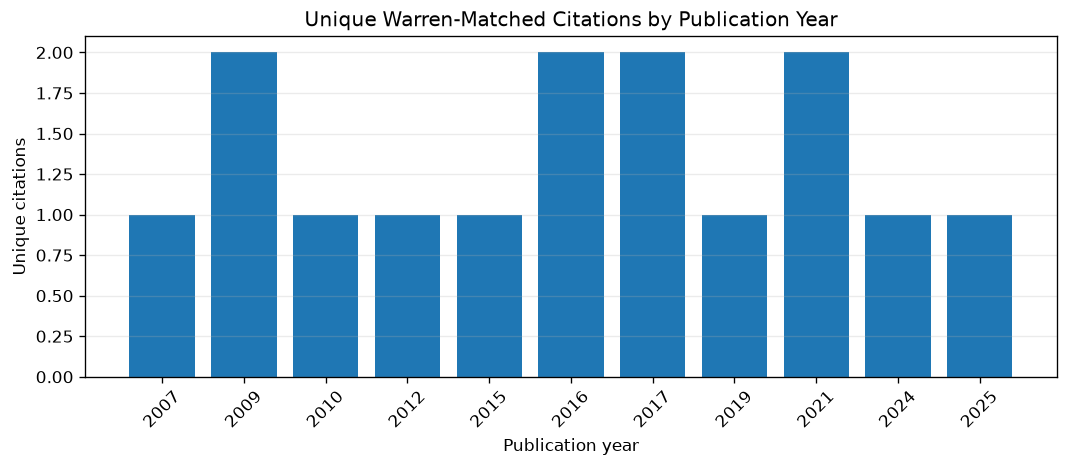

In [15]:
# Plot the number of unique citations by publication year.

if (
    unique_citations.empty
    or unique_citations["publication_year"].dropna().empty
):
    publication_counts = pd.Series(dtype="int64")
    print("Publication-year data is unavailable.")
else:
    publication_counts = (
        unique_citations["publication_year"]
        .dropna()
        .astype(int)
        .value_counts()
        .sort_index()
    )

    fig, ax = plt.subplots(figsize=(9, 4))

    ax.bar(
        publication_counts.index.astype(str),
        publication_counts.values,
    )

    ax.set_title(
        "Unique Warren-Matched Citations by Publication Year"
    )
    ax.set_xlabel("Publication year")
    ax.set_ylabel("Unique citations")
    ax.grid(axis="y", alpha=0.25)

    plt.xticks(rotation=45)
    plt.tight_layout()
    display_figure(fig)

## 9. Summarize Analysis Types and Methods

The complete citations table is used for this section because each row
represents a citation, dataset, and analysis-type combination.

The analysis-type counts describe the categories returned by PetDB. The
method counts summarize the analytical methods recorded in the citation and
dataset metadata.

These values describe metadata records rather than individual laboratory
measurements.

In [16]:
# Count analysis types and individual analytical methods.

if citations.empty:
    analysis_counts = pd.Series(dtype="int64")
    method_counts = pd.Series(dtype="int64")
else:
    analysis_counts = (
        citations["analysisType"]
        .dropna()
        .astype(str)
        .str.strip()
        .replace("", np.nan)
        .dropna()
        .value_counts()
        .sort_values()
    )

    method_counts = (
        citations["methods"]
        .dropna()
        .astype(str)
        .str.split(",")
        .explode()
        .str.strip()
        .replace("", np.nan)
        .dropna()
        .value_counts()
        .head(8)
        .sort_values()
    )

print("Analysis types:")
display(analysis_counts)

print("\nMost frequent analytical methods:")
display(method_counts)

Analysis types:


analysisType
Inclusion Analysis     1
Rock Analysis         22
Mineral Analysis      48
Name: count, dtype: int64


Most frequent analytical methods:


methods
THERMAL IONIZATION MASS SPECTROMETRY ISOTOPE DILUTION           3
INDUCTIVELY COUPLED PLASMA MASS SPECTROMETRY                    4
ION MICROPROBE                                                  4
POINT COUNTING                                                  5
LASER ABLATION INDUCTIVELY COUPLED PLASMA MASS SPECTROMETRY     7
THERMAL IONIZATION MASS SPECTROMETRY                            7
CALCULATED                                                     26
ELECTRON MICROPROBE                                            38
Name: count, dtype: int64

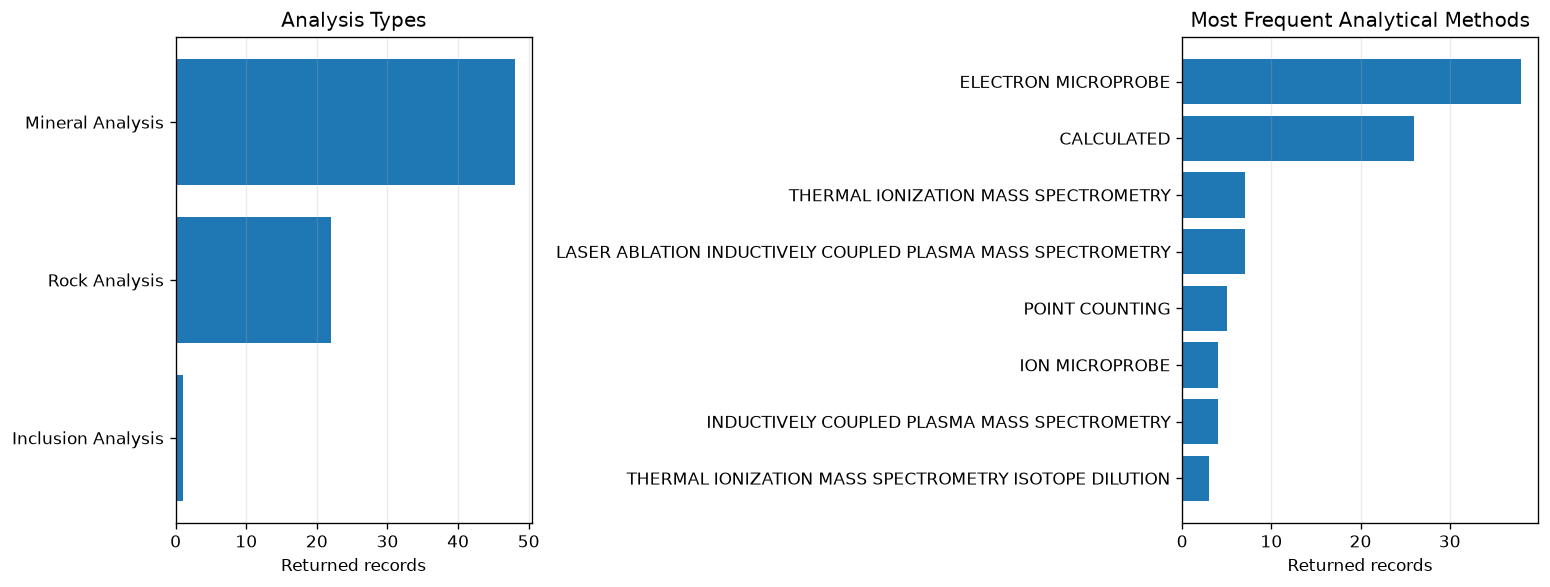

In [17]:
# Visualize the returned analysis types and analytical methods.

if analysis_counts.empty and method_counts.empty:
    print("No analysis-type or method metadata was returned.")
else:
    fig, axes = plt.subplots(
        nrows=1,
        ncols=2,
        figsize=(13, 5),
    )

    if analysis_counts.empty:
        axes[0].text(
            0.5,
            0.5,
            "No analysis-type data",
            ha="center",
            va="center",
        )
        axes[0].set_axis_off()
    else:
        axes[0].barh(
            analysis_counts.index,
            analysis_counts.values,
        )
        axes[0].set_title("Analysis Types")
        axes[0].set_xlabel("Returned records")
        axes[0].grid(axis="x", alpha=0.25)

    if method_counts.empty:
        axes[1].text(
            0.5,
            0.5,
            "No method data",
            ha="center",
            va="center",
        )
        axes[1].set_axis_off()
    else:
        axes[1].barh(
            method_counts.index,
            method_counts.values,
        )
        axes[1].set_title("Most Frequent Analytical Methods")
        axes[1].set_xlabel("Returned records")
        axes[1].grid(axis="x", alpha=0.25)

    plt.tight_layout()
    display_figure(fig)

## 10. Interpretation

The `Warren` author query returned a geographically broad collection rather
than a collection limited to southwestern Nevada. The sample coordinates span
multiple oceanic and continental regions.

The citation metadata shows that the returned publications are primarily
associated with researchers such as J. M. Warren and J. E. Warren. Many of the
publications concern oceanic mantle processes, peridotites, mid-ocean ridges,
and related geochemical studies.

This result demonstrates an important property of author-based repository
searches: a surname query can match multiple researchers. The returned records
should therefore be interpreted as a `Warren` search cohort rather than as
records belonging to one specific researcher.

Mineral Analysis is the most frequent analysis type in the returned metadata.
Electron Microprobe is the most frequently recorded analytical method.

The results also have two important technical limitations:

1. The samples and citations cannot currently be joined at the individual
   record level.
2. The notebook analyzes only the API page returned by the current backend.

In [18]:
# Print the main results from the user story.

print("NAVDAT USER STORY SUMMARY")
print("-" * 40)
print(f"Author query: {AUTHOR_QUERY}")
print(f"Retrieved samples: {len(samples):,}")
print(
    "Location groups:",
    f"{samples['rootParent'].nunique():,}",
)
print(
    "Samples with valid coordinates:",
    f"{len(samples_geo):,}",
)
print(
    "Unique citations:",
    f"{len(unique_citations):,}",
)

if not samples_geo.empty:
    print(
        "Latitude range:",
        f"{samples_geo['latitude'].min():.2f}",
        "to",
        f"{samples_geo['latitude'].max():.2f}",
    )

    print(
        "Longitude range:",
        f"{samples_geo['longitude'].min():.2f}",
        "to",
        f"{samples_geo['longitude'].max():.2f}",
    )

if not analysis_counts.empty:
    print(
        "Most frequent analysis type:",
        analysis_counts.idxmax(),
    )

if not method_counts.empty:
    print(
        "Most frequent analytical method:",
        method_counts.idxmax(),
    )

NAVDAT USER STORY SUMMARY
----------------------------------------
Author query: Warren
Retrieved samples: 321
Location groups: 100
Samples with valid coordinates: 321
Unique citations: 15
Latitude range: -54.06 to 86.76
Longitude range: -175.42 to 66.87
Most frequent analysis type: Mineral Analysis
Most frequent analytical method: ELECTRON MICROPROBE


## 11. Role of DSI and Current Limitations

Without the DSI NAVDAT backend, a researcher would need to call separate PetDB
endpoints, traverse nested location groups, flatten sample records, normalize
citation arrays, and organize the results before beginning analysis.

With DSI, the workflow becomes:

**Author query → DSI NAVDAT → samples and citations → geographic and metadata analysis**

DSI provides the repository-access and normalization layer. Pandas and
Matplotlib provide the downstream analysis and visualization.

The current workflow has several limitations:

- Pagination is not implemented, so the notebook analyzes one API page.
- Individual samples cannot be connected directly to citation records.
- A surname query may match several researchers.
- The backend returns metadata rather than measured geochemical values.
- The live PetDB service may change its data or response behavior.

## Conclusion

This notebook used the DSI NAVDAT backend to retrieve and analyze sample and
citation metadata for the author query `Warren`.

DSI converted nested PetDB responses into analysis-ready tables. The workflow
mapped the returned samples, identified the largest location groups, reviewed
the unique citations, and summarized the principal analysis types and
analytical methods.

The global sample distribution and citation authors demonstrate that the
surname query represents several Warren-associated studies rather than one
specific southwestern Nevada researcher.

The notebook therefore demonstrates both the value of DSI's normalized
repository access and the importance of validating broad search results before
using them for scientific interpretation.

In [19]:
# Close the backend and clear its in-memory state.

dsi.close()

print("NAVDAT backend closed.")

Closing this instance of DSI()
NAVDAT backend closed.
